# Partie 1 - Analyse Exploratoire des Donnees

Ce notebook documente l'exploration initiale du dataset RH : structure, qualite des donnees, distributions, premiers signaux sur l'attrition et variables potentiellement utiles pour la suite du projet.


In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
df = load_data(DATA_PATH)
pd.set_option("display.max_columns", 100)


## 1. Chargement et vue d'ensemble

On commence par verifier la taille du dataset, le taux d'attrition et la presence de donnees manquantes.


In [2]:
dataset_overview(df)


,Indicateur,Valeur
0,Nombre de lignes,8020.0
1,Variables sources,28.0
2,Variables ajoutees,6.0
3,Taux d'attrition (%),18.8
4,Cellules manquantes (source),482.0
5,employee_id dupliques,20.0


In [3]:
df.head()


,employee_id,age,gender,country,department,job_role,education_level,school_tier,parental_status,accented_name_flag,contracted_hours_weekly,years_at_company,manager_level,remote_ratio,performance_rating,engagement_score,training_hours,internal_mobility_count,promotion_last_3y,absenteeism_days,overtime_hours,manager_favoritism_score,visibility_score,psychological_safety_score,salary,bonus,stock_options,attrition,age_group,remote_band,engagement_band,overtime_band,absence_band,salary_quartile
0,EMP_100000,25,Male,Canada,Data,Data Scientist,Master,Tier 2,Parent,0,35,4,0,0,3.07,76.138401,26,0,0,15,3,59.4,61.9,52.1,59751.0,543,4396,0,<30,0%,High,0-5,11+,Q2
1,EMP_100001,33,Female,Germany,Sales,Sales Executive,Bachelor,Tier 3,Parent,1,28,3,0,25,3.48,72.365510,23,1,0,27,3,58.1,50.6,39.7,58502.0,6895,514,0,30-39,25%,High,0-5,11+,Q2
2,EMP_100002,34,Male,France,HR,Talent Manager,Master,Tier 2,No Children,0,28,4,0,25,3.81,81.316227,51,0,0,25,3,76.0,64.8,44.8,57278.0,1887,2504,0,30-39,25%,Very High,0-5,11+,Q2
3,EMP_100003,38,Male,France,Data,Data Engineer,Master,Tier 2,No Children,0,28,10,0,75,3.96,69.305706,29,0,0,20,25,79.8,54.6,33.2,72989.0,8585,986,1,30-39,75%,Medium,16-25,11+,Q4
4,EMP_100004,36,Male,Germany,IT,DevOps Engineer,Bachelor,Tier 1,No Children,0,35,10,1,100,1.84,73.182769,27,0,1,9,27,38.8,52.5,68.6,81888.0,1530,1782,0,30-39,100%,High,26+,6-10,Q4


## 2. Variables et qualite de donnees

Le CSV reel contient 28 variables. Par rapport a l'enonce initial, on note notamment la presence de `years_at_company` et `accented_name_flag`, tandis que `salary_band` n'est pas present.


In [4]:
missing_summary(df)


,missing_count,missing_pct,dtype
performance_rating,161,2.01,float64
salary,161,2.01,float64
engagement_score,160,2.00,float64


In [5]:
numeric_summary(df).head(15)


,mean,std,min,25%,50%,75%,max
age,35.78,8.43,22.0,30.00,36.00,42.00,63.0
accented_name_flag,0.20,0.40,0.0,0.00,0.00,0.00,1.0
contracted_hours_weekly,33.00,3.16,28.0,28.00,35.00,35.00,35.0
years_at_company,4.99,4.07,0.0,1.00,5.00,8.00,24.0
manager_level,0.51,0.80,0.0,0.00,0.00,1.00,3.0
remote_ratio,51.22,31.22,0.0,25.00,50.00,75.00,100.0
performance_rating,3.45,0.69,1.0,2.98,3.46,3.93,5.0
engagement_score,67.79,14.74,20.0,58.01,67.75,78.04,100.0
training_hours,34.47,17.36,0.0,22.00,34.00,46.00,96.0
internal_mobility_count,0.98,1.00,0.0,0.00,1.00,2.00,7.0


## 3. Distribution de la cible

L'attrition represente desormais environ **18,8 %** des effectifs. La classe positive reste minoritaire, mais le desequilibre est nettement moins extreme que dans la version precedente du dataset, ce qui rend la prediction plus exploitable.


In [6]:
attrition_table = attrition_by_group(df, "attrition", ascending=True)
attrition_table


,attrition,effectif,departs,attrition_rate_pct
0,0,6512,0,0.0
1,1,1508,1508,100.0


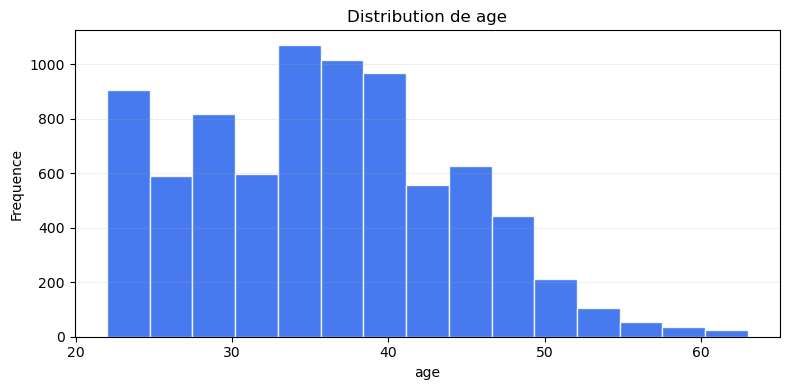

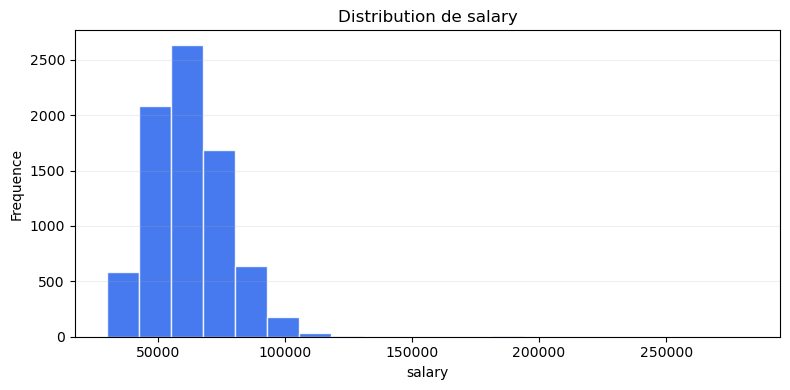

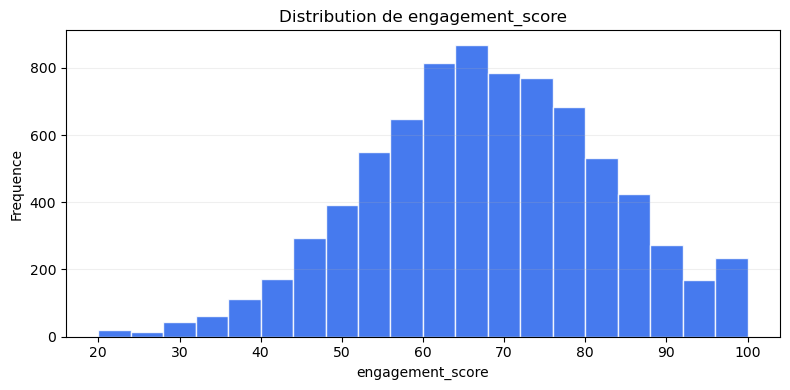

In [7]:
plot_histogram(df, "age", bins=15)
plot_histogram(df, "salary", bins=20)
plot_histogram(df, "engagement_score", bins=20)


## 4. Premiers signaux par segment

Cette section cherche a identifier les segments ou le turnover semble plus eleve, avant toute modelisation.


In [8]:
attrition_department = attrition_by_group(df, "department")
attrition_country = attrition_by_group(df, "country")
attrition_remote = attrition_by_group(df, "remote_band", ascending=True)

display(attrition_department)
display(attrition_country)
display(attrition_remote)


,department,effectif,departs,attrition_rate_pct
3,HR,1036,223,21.53
2,Finance,950,196,20.63
7,Sales,1005,201,20.00
0,Customer Support,1027,195,18.99
1,Data,1042,188,18.04
4,IT,970,170,17.53
5,Marketing,972,170,17.49
6,Operations,1018,165,16.21


,country,effectif,departs,attrition_rate_pct
3,Spain,1281,257,20.06
1,France,1338,263,19.66
4,UK,1342,252,18.78
5,USA,1347,250,18.56
2,Germany,1356,244,17.99
0,Canada,1356,242,17.85


,remote_band,effectif,departs,attrition_rate_pct
0,0%,1224,212,17.32
4,75%,1556,285,18.32
1,100%,1226,229,18.68
2,25%,1169,225,19.25
3,50%,2845,557,19.58


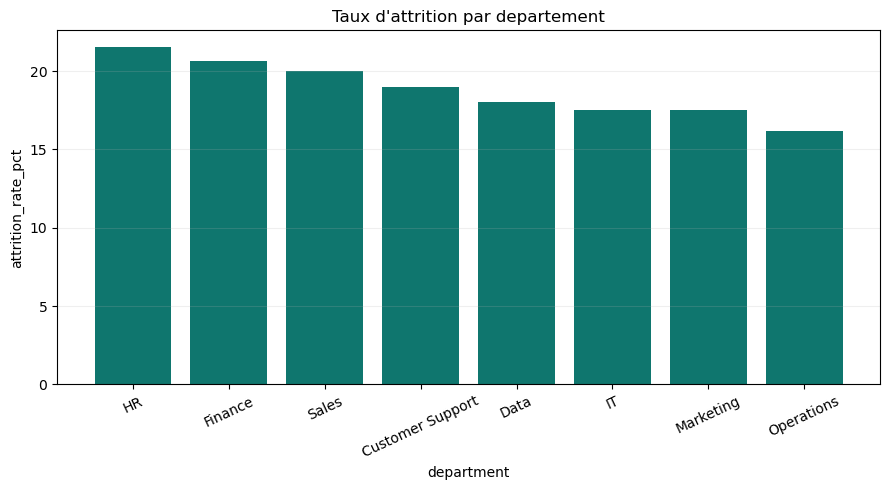

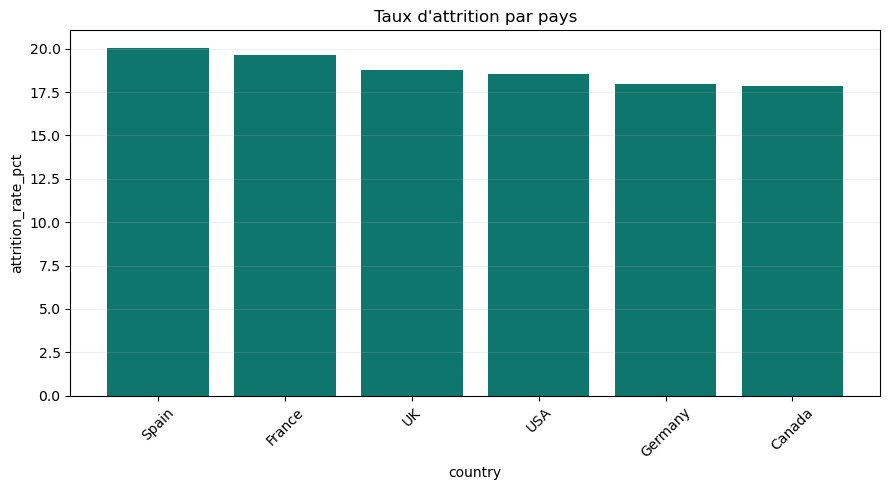

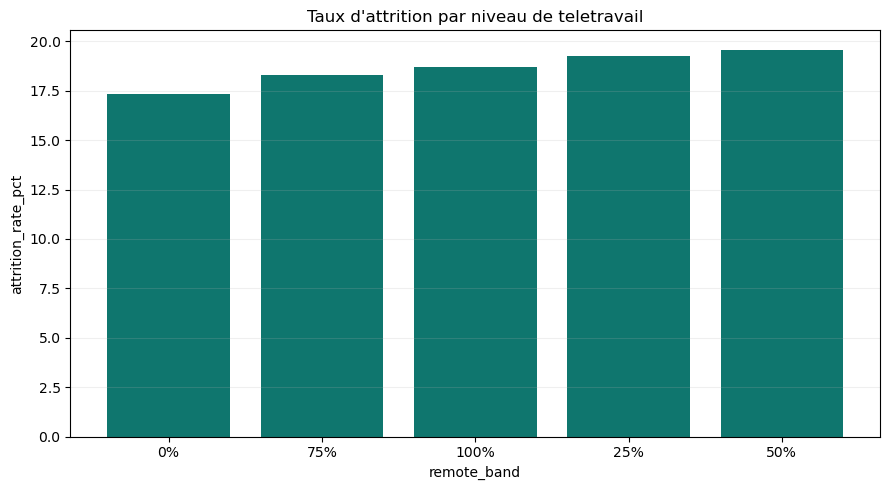

In [9]:
plot_bar(attrition_department, "department", "attrition_rate_pct", title="Taux d'attrition par departement", rotation=25)
plot_bar(attrition_country, "country", "attrition_rate_pct", title="Taux d'attrition par pays")
plot_bar(attrition_remote, "remote_band", "attrition_rate_pct", title="Taux d'attrition par niveau de teletravail", rotation=0)


## 5. Variables numeriques et attrition

On compare ensuite plusieurs dimensions RH entre les collaborateurs restes et ceux ayant quitte l'entreprise.


In [10]:
attrition_gap_summary(df)


,depart_mean,reste_mean,ecart_depart_moins_reste
engagement_score,66.59,68.07,-1.48
psychological_safety_score,44.12,55.94,-11.83
overtime_hours,23.14,20.56,2.58
absenteeism_days,21.03,12.23,8.80
training_hours,33.93,34.60,-0.67
salary,61138.36,62602.31,-1463.95
visibility_score,64.78,64.81,-0.03
manager_favoritism_score,59.45,60.85,-1.41
years_at_company,4.61,5.07,-0.46
internal_mobility_count,0.48,1.09,-0.61


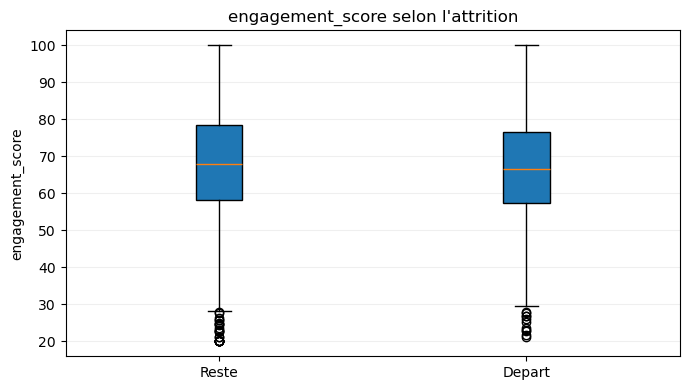

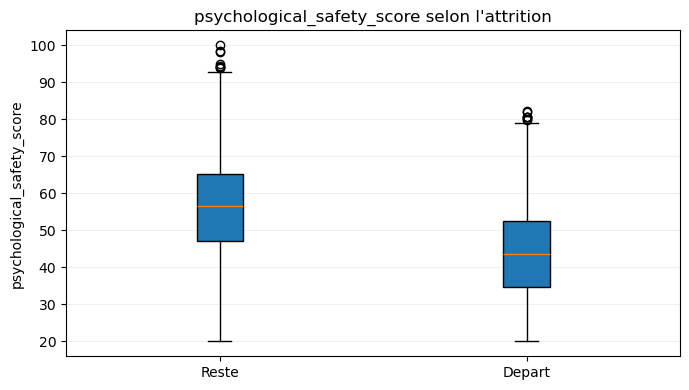

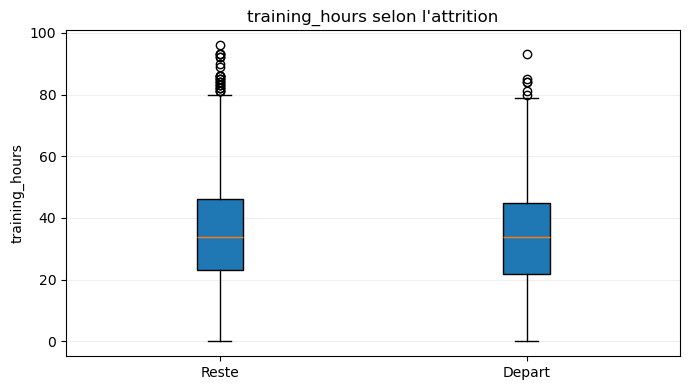

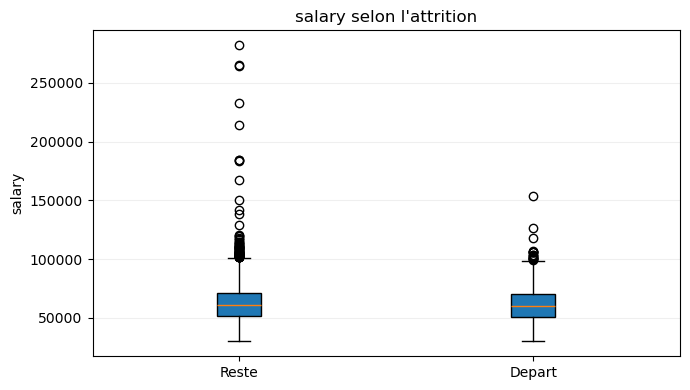

In [11]:
plot_box_by_attrition(df, "engagement_score")
plot_box_by_attrition(df, "psychological_safety_score")
plot_box_by_attrition(df, "training_hours")
plot_box_by_attrition(df, "salary")


In [12]:
correlation_with_attrition(df)


attrition                     1.000
absenteeism_days              0.441
overtime_hours                0.086
accented_name_flag            0.015
performance_rating            0.011
remote_ratio                  0.005
stock_options                 0.005
manager_level                 0.001
visibility_score             -0.001
training_hours               -0.015
age                          -0.017
bonus                        -0.027
salary                       -0.036
engagement_score             -0.039
years_at_company             -0.044
manager_favoritism_score     -0.051
promotion_last_3y            -0.149
internal_mobility_count      -0.238
contracted_hours_weekly      -0.302
psychological_safety_score   -0.327
Name: attrition, dtype: float64

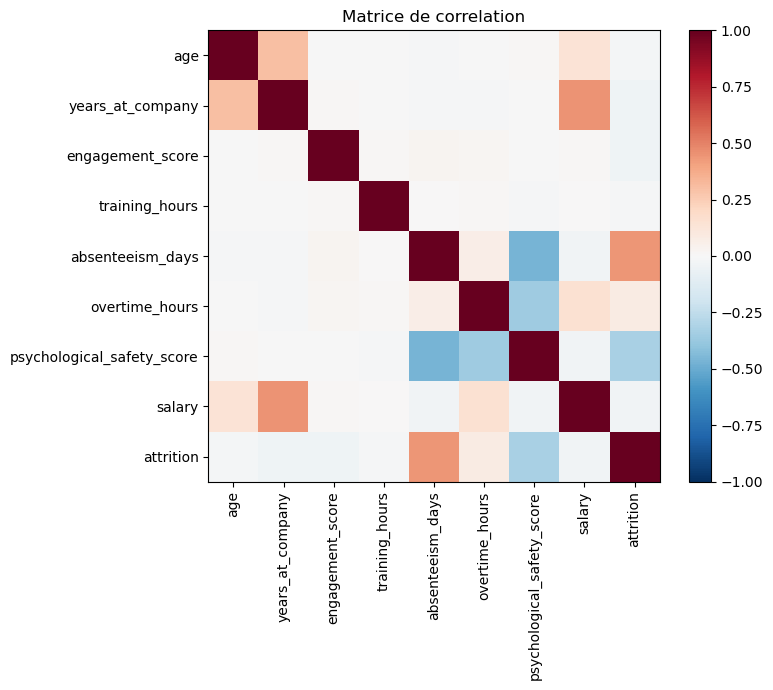

In [13]:
plot_correlation_heatmap(
    df,
    columns=[
        "age",
        "years_at_company",
        "engagement_score",
        "training_hours",
        "absenteeism_days",
        "overtime_hours",
        "psychological_safety_score",
        "salary",
        "attrition",
    ],
    figsize=(9, 7),
)


## 6. Faits marquants EDA

- Le dataset couvre **8 020 collaborateurs** et presente un **taux d'attrition de 18,8 %**.
- Les principales valeurs manquantes concernent `performance_rating`, `engagement_score` et `salary`, mais dans des proportions limitees.
- Les pays et departements ne sont pas exposes de maniere uniforme : **l'Espagne** et **la France** sont les pays les plus touches, tandis que **HR** et **Finance** ressortent comme les departements les plus exposes.
- Les collaborateurs partis montrent en moyenne un **engagement plus bas**, une **securite psychologique beaucoup plus faible**, **davantage d'absences**, **plus d'heures supplementaires**, **moins de mobilite interne** et un **salaire un peu plus faible**.
- Le signal apparait plus structure qu'auparavant, en particulier autour de l'**absenteisme**, de la **securite psychologique**, des **heures supplementaires** et de la **mobilite interne**.
